# Análise Exploratória — Online Retail

## Objetivo
Entender os fatores que explicam a variação da receita ao longo do tempo.

## Pergunta principal
Quais fatores explicam a variação da receita ao longo do tempo?

## Perguntas secundárias
- Existe sazonalidade?
- Produtos específicos impactam mais?
- Datas comemorativas influenciam?
- Qual o impacto das devoluções?
- Países influenciam desproporcionalmente?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/data.csv", encoding="ISO-8859-1")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# Convertendo InvoiceDate para datetime para permitir análise temporal.

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


# Criando coluna "Revenue" para analisar a receita da empresa.

In [10]:
df["Revenue"]= df["Quantity"] * df["UnitPrice"]

# Analisando se existem devoluções que podem afetar a variação da receita.

In [11]:
df[df["Quantity"] < 0].shape

(10624, 9)

In [12]:
df[df["Revenue"] < 0].shape

(9290, 9)

# Medindo o impacto financeiro das devoluções.

In [13]:
# Receita total
total_revenue= df["Revenue"].sum()

# Receita negativa (devoluções)
negative_revenue= df[df["Revenue"]< 0]["Revenue"].sum()

total_revenue, negative_revenue

(np.float64(9747747.934), np.float64(-918936.61))

In [14]:
abs(negative_revenue) / total_revenue

np.float64(0.09427168369780703)

# Analisando se as devoluções são um ponto preocupante

In [15]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [16]:
# Receita bruta
gross = df[df["Quantity"] > 0].groupby("YearMonth")["Revenue"].sum()

In [17]:
# Receita de devoluções
returns = df[df["Quantity"] < 0].groupby("YearMonth")["Revenue"].sum()

In [18]:
# Receita Líquida
net = df.groupby("YearMonth")["Revenue"].sum()

In [19]:
monthly = pd.concat([gross, returns, net], axis=1)
monthly.columns = ["GrossRevenue", "ReturnsRevenue", "NetRevenue"]

# Analisar meses específicos

In [20]:
monthly.loc["2010-01":"2010-12"]

,GrossRevenue,ReturnsRevenue,NetRevenue
YearMonth,,,
2010-12,823746.14,-74789.12,748957.02


In [21]:
monthly["NetRevenue"].min()

np.float64(433668.01)

In [22]:
monthly["NetRevenueChange"] = monthly["NetRevenue"].pct_change()
monthly.sort_values("NetRevenueChange")

,GrossRevenue,ReturnsRevenue,NetRevenue,NetRevenueChange
YearMonth,,,,
2011-12,638792.680,-205124.67,433668.010,-0.703324
2011-04,537808.621,-44601.50,493207.121,-0.278163
2011-01,691364.560,-131364.30,560000.260,-0.252293
2011-02,523631.890,-25569.24,498062.650,-0.110603
2011-06,761739.900,-70616.78,691123.120,-0.044530
2011-07,719221.191,-37921.08,681300.111,-0.014213
2011-08,737014.260,-54333.75,682680.510,0.002026
2011-10,1154979.300,-84274.63,1070704.670,0.050032
2011-11,1509496.330,-47740.08,1461756.250,0.365228


In [23]:
monthly.loc["2011-04"]

GrossRevenue        537808.621000
ReturnsRevenue      -44601.500000
NetRevenue          493207.121000
NetRevenueChange        -0.278163
Name: 2011-04, dtype: float64

In [24]:
monthly.loc["2011-03"]

GrossRevenue        717639.36000
ReturnsRevenue      -34372.28000
NetRevenue          683267.08000
NetRevenueChange         0.37185
Name: 2011-03, dtype: float64

Após análise dos meses, a queda de receita em abril de 2011 foi causada principalmente pela redução no volume de vendas, e não pelo aumento nas devoluções.

# Analisando qual produto foi responsável pela queda das vendas em abril:

In [25]:
df_sales = df[df["Quantity"] > 0]

In [26]:
product_month = df_sales.groupby(
    ["YearMonth", "Description"]
)["Revenue"].sum().reset_index()

In [27]:
mar = product_month[product_month["YearMonth"] == "2011-03"]
apr = product_month[product_month["YearMonth"] == "2011-04"]

In [28]:
compare = mar.merge(
    apr,
    on="Description",
    how="outer",
    suffixes=("_Mar", "_Apr")
).fillna(0)

In [29]:
compare["Diff"] = compare["Revenue_Apr"] - compare["Revenue_Mar"]

In [30]:
compare.sort_values("Diff")

,YearMonth_Mar,Description,Revenue_Mar,YearMonth_Apr,Revenue_Apr,Diff
1285,2011-03,JUMBO BAG RED RETROSPOT,10118.38,2011-04,4878.08,-5240.30
1289,2011-03,JUMBO BAG STRAWBERRY,5853.80,2011-04,1034.79,-4819.01
2609,2011-03,VINTAGE UNION JACK BUNTING,5299.33,2011-04,492.25,-4807.08
762,2011-03,DOTCOM POSTAGE,11829.71,2011-04,7535.38,-4294.33
2182,2011-03,SET OF 3 CAKE TINS PANTRY DESIGN,4192.95,2011-04,407.57,-3785.38
...,...,...,...,...,...,...
2488,0,TEA TIME TEA TOWELS,0.00,2011-04,2730.00,2730.00
739,2011-03,DOORMAT FAIRY CAKE,1725.52,2011-04,4961.50,3235.98
1018,2011-03,GIN + TONIC DIET METAL SIGN,1306.04,2011-04,4612.54,3306.50
2646,2011-03,WHITE HANGING HEART T-LIGHT HOLDER,5597.90,2011-04,10017.79,4419.89


A queda na receita em abril de 2011 não foi causada por um único produto, mas sim por uma redução generalizada nas vendas de diversos itens relevantes. Apesar disso, alguns produtos apresentaram crescimento, indicando uma possível mudança no comportamento de compra dos clientes, ao invés de uma queda uniforme na demanda.

<Axes: xlabel='YearMonth'>

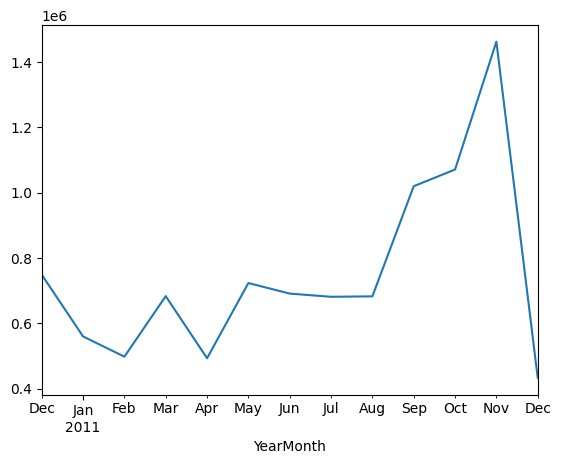

In [31]:
monthly["NetRevenue"].plot()

<Axes: xlabel='YearMonth'>

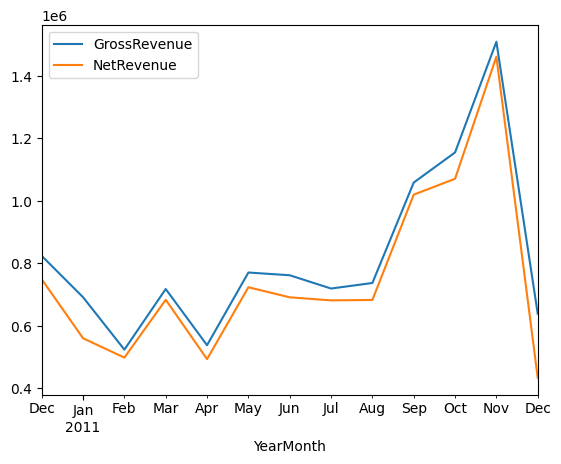

In [32]:
monthly[["GrossRevenue", "NetRevenue"]].plot()

In [33]:
monthly["Month"] = monthly.index.month

In [34]:
monthly.groupby("Month")["NetRevenue"].mean()

Month
1      560000.260
2      498062.650
3      683267.080
4      493207.121
5      723333.510
6      691123.120
7      681300.111
8      682680.510
9     1019687.622
10    1070704.670
11    1461756.250
12     591312.515
Name: NetRevenue, dtype: float64

Observa-se um pico significativo na receita em novembro, sugerindo possível influência de eventos sazonais como o período de fim de ano. No entanto, como o dataset cobre apenas um ciclo anual, não é possível afirmar com certeza a existência de um padrão sazonal recorrente.

# Análise por Países

In [35]:
country_rev = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_rev.head(10)

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

In [36]:
country_pct = country_rev / country_rev.sum()
country_pct.head(10)

Country
United Kingdom    0.839969
Netherlands       0.029203
EIRE              0.027009
Germany           0.022744
France            0.020251
Australia         0.014062
Switzerland       0.005784
Spain             0.005619
Belgium           0.004197
Sweden            0.003754
Name: Revenue, dtype: float64

A análise geográfica mostra que o Reino Unido é responsável pela grande maioria da receita, com uma diferença significativa em relação aos demais países. Isso indica uma forte concentração de mercado e baixa diversificação geográfica.
